In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("cleaned_match_results_data.csv", parse_dates=["date"])

In [3]:
data.dtypes

date                datetime64[ns]
name                        object
division                    object
place                       object
match_points               float64
match_percentage            object
dtype: object

In [4]:
data["match_percentage"] = data["match_percentage"].str.replace(
    "%", "").astype(float)

In [5]:
sorted_data = data.sort_values("date", ascending=True)
sorted_data["match_percentage"] = sorted_data["match_percentage"].round(2)
sorted_data["match_points"] = sorted_data["match_points"].round(2)

In [6]:
sorted_data.head()

,date,name,division,place,match_points,match_percentage
410,2025-05-28,"Chamont, Brad",Standard,5,157.34,71.52
306,2025-05-28,"Gillespie, Josh 2",Combined,57,39.32,17.10
305,2025-05-28,"Gillespie, Josh",Combined,56,40.53,17.62
304,2025-05-28,"Masike, Tebogo",Combined,55,41.50,18.05
303,2025-05-28,"Tshabalala, Dumisani Alexius 2",Combined,54,42.50,18.48


In [7]:
dez_df = sorted_data[sorted_data["name"] == "Coetzee, Desmond"]

In [8]:
len(dez_df)

20

In [9]:
dez_df.head()

,date,name,division,place,match_points,match_percentage
278,2025-05-28,"Coetzee, Desmond",Combined,29,82.72,35.97
376,2025-05-28,"Coetzee, Desmond",Production,6,163.65,74.39
346,2025-05-28,"Coetzee, Desmond",Combined,30,121.57,55.98
243,2025-06-04,"Coetzee, Desmond",Combined,16,95.84,44.85
200,2025-06-04,"Coetzee, Desmond",Production,16,36.57,33.25


In [10]:
median_points = data["match_points"].median()

Text(0.5, 1.0, 'Dez Match Points over time vs Median')

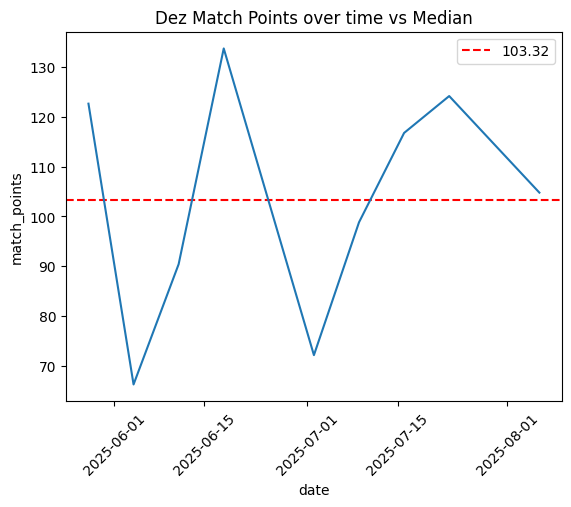

In [11]:
plt.xticks(rotation=45)
plt.axhline(median_points, color="red", linestyle="--",
            label=f"{median_points:.2f}")
sns.lineplot(data=dez_df, x="date", y="match_points", errorbar=None)
plt.title("Dez Match Points over time vs Median")

In [12]:
median_percentage = data["match_percentage"].median()

Text(0.5, 1.0, 'Dez Match Percentage over time vs Median')

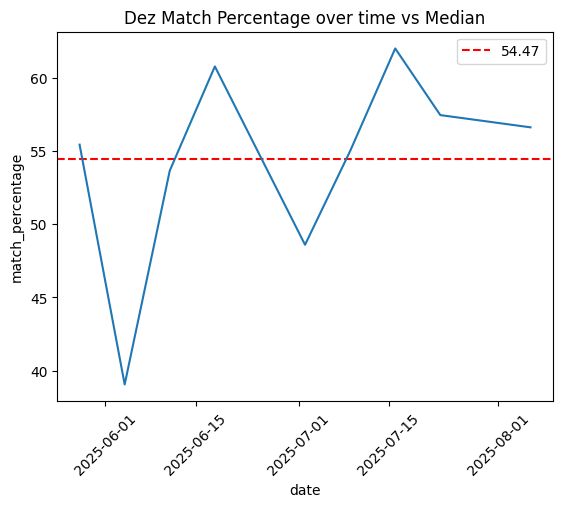

In [13]:
plt.xticks(rotation=45)
plt.axhline(median_percentage, color="red", linestyle="--",
            label=f"{median_percentage:.2f}")
sns.lineplot(data=dez_df, x="date", y="match_percentage", errorbar=None)
plt.title("Dez Match Percentage over time vs Median")

<Axes: xlabel='match_points', ylabel='match_percentage'>

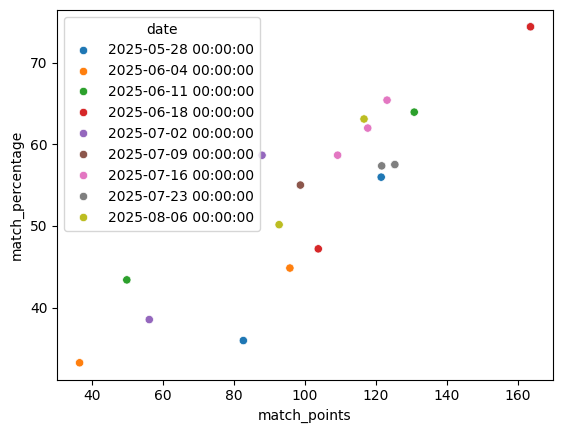

In [14]:
sns.scatterplot(data=dez_df, x="match_points",
                y="match_percentage", hue="date")

In [15]:
stage_data = pd.read_csv(
    "cleaned_stage_results_data.csv", parse_dates=["date"])

In [16]:
stage_data.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
0,2025-07-09,1,"Plein, Aubrey",C,0,18.08,3.9823,75.0000,100.00%,2
1,2025-07-09,1,"Da Cruz, David",PCCO,0,9.33,7.3955,75.0000,100.00%,2
2,2025-07-09,2,"Rabie, Theo",PCCO,0,10.30,6.8932,69.9061,93.21%,2
3,2025-07-09,3,"Morris, Bevan",PCCO,0,12.12,5.8581,59.4086,79.21%,2
4,2025-07-09,4,"Hepton, Harry",PCCO,0,17.40,3.9655,40.2155,53.62%,2


In [17]:
sorted_stage_data = stage_data.sort_values("date", ascending=True)
sorted_stage_data["stage points"] = sorted_stage_data["stage points"].round(2)
sorted_stage_data["stage percentage"] = sorted_stage_data["stage percentage"].str.replace(
    "%", "").astype(float)
sorted_stage_data["stage percentage"] = sorted_stage_data["stage percentage"].round(
    2)
sorted_stage_data["hit factor"] = sorted_stage_data["hit factor"].round(2)

In [18]:
sorted_stage_data.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
0,2025-07-09,1,"Plein, Aubrey",C,0,18.08,3.98,75.00,100.00,2
80,2025-07-09,26,"Faurie, Zander 2",P,0,29.93,2.31,42.49,40.47,1
78,2025-07-09,24,"Levinrad, Dayne",P,0,27.05,2.44,45.00,42.85,1
77,2025-07-09,23,"Faurie, Zander",P,0,25.86,2.51,46.35,44.13,1
76,2025-07-09,22,"Gillespie, Graham 3",P,0,23.31,2.57,47.45,45.18,1


In [19]:
stage_1_data = sorted_stage_data[sorted_stage_data["stage_number"] == 1]
stage_2_data = sorted_stage_data[sorted_stage_data["stage_number"] == 2]

In [20]:
stage_1_data.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
80,2025-07-09,26,"Faurie, Zander 2",P,0,29.93,2.31,42.49,40.47,1
78,2025-07-09,24,"Levinrad, Dayne",P,0,27.05,2.44,45.00,42.85,1
77,2025-07-09,23,"Faurie, Zander",P,0,25.86,2.51,46.35,44.13,1
76,2025-07-09,22,"Gillespie, Graham 3",P,0,23.31,2.57,47.45,45.18,1
75,2025-07-09,21,"Faurie, Zander 3",P,0,24.08,2.62,48.24,45.94,1


In [21]:
stage_2_data.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
0,2025-07-09,1,"Plein, Aubrey",C,0,18.08,3.98,75.00,100.00,2
24,2025-07-09,18,"Levinrad, Dayne 2",P,10,65.03,0.86,13.72,18.29,2
23,2025-07-09,17,"Levinrad, Dayne",P,20,28.94,0.86,13.76,18.35,2
22,2025-07-09,16,"Rahman, Aqeel",P,30,17.63,0.91,14.46,19.27,2
21,2025-07-09,15,"Jones, Nicholas",P,30,18.62,1.29,20.53,27.37,2


In [22]:
dez_stage_1 = stage_1_data[stage_1_data["name"] == "Coetzee, Desmond"]
dez_stage_2 = stage_2_data[stage_2_data["name"] == "Coetzee, Desmond"]

In [23]:
dez_stage_1.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
63,2025-07-09,9,"Coetzee, Desmond",P,0,17.10,3.65,67.30,64.10,1
184,2025-07-23,19,"Coetzee, Desmond",P,0,24.32,3.82,45.16,42.99,1
267,2025-08-06,6,"Coetzee, Desmond",P,0,11.28,7.98,54.10,60.11,1


In [24]:
dez_stage_2.head()

,date,place,name,division,penalty,time,hit factor,stage points,stage percentage,stage_number
14,2025-07-09,8,"Coetzee, Desmond",P,10,21.57,2.60,41.35,55.14,2
127,2025-07-23,15,"Coetzee, Desmond",P,0,23.33,4.46,55.30,50.27,2
150,2025-07-23,38,"Coetzee, Desmond",P,40,29.48,0.98,12.20,11.10,2
219,2025-08-06,7,"Coetzee, Desmond",P,0,21.38,3.79,58.46,61.53,2


In [25]:
len(stage_1_data)

157

In [26]:
len(stage_2_data)

151

In [27]:
len(dez_stage_1)

3

In [28]:
len(dez_stage_2)

4

In [ ]:
combined_data = pd.read_csv(
    "cleaned_combined_stage_results.csv", parse_dates=["Date"])

In [32]:
len(combined_data)

167

In [33]:
dez_combined = combined_data[combined_data["Name"] == "Coetzee, Desmond"]

In [34]:
len(dez_combined)

4

In [35]:
dez_combined

,Date,Place,Name,Division,Match Points,Match Percentage
18,2025-07-02,19,"Coetzee, Desmond",P,57.6694,38.4463%
70,2025-07-09,34,"Coetzee, Desmond",P,98.8005,55.0072%
108,2025-07-23,23,"Coetzee, Desmond",P,125.3990,57.5240%
138,2025-08-06,9,"Coetzee, Desmond",P,92.8031,50.1638%
